In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.utils.data as data_utils
from torch.nn import Module

import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

# PyTorch 101

This is my first approach to `PyTorch`, tackling a **Classification** task on the well-known *Iris* dataset using a Neural Network.

The following exercise includes:

- Exploring the *Iris* dataset.
- Preprocessing the dataset to make it compatible with PyTorch.
- Building a simple Neural Network for multi-class classification.
- Training the Neural Network while monitoring training and validation loss and accuracy.
- Plotting the learning curves from the training history.
- Evaluating the model on the test set.

In [3]:
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED);

## Dataset

The *Iris* dataset is a classic benchmark for classification. It contains measurements from 150 iris flowers across 3 species.

**Features:**
- `sepal length (cm)`: length of the sepal
- `sepal width (cm)`: width of the sepal
- `petal length (cm)`: length of the petal
- `petal width (cm)`: width of the petal

**Target:**
- `species`: iris species — *Setosa* (0), *Versicolor* (1), *Virginica* (2)

In [4]:
# load data as dataframe object
data, target = load_iris(return_X_y=True, as_frame=True)

### Exploratory Data Analysis

Let's explore the dataset to understand the feature distributions, value ranges, and check for any missing values.

In [5]:
# check data
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
# check for null values
data.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [7]:
# exploring the dataset
data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Data Splitting

We use a **three-way split** — a common deep learning practice — to keep the roles of each subset clearly separated:

- **Train** (70%): used to update model weights during backpropagation.
- **Validation** (15%): used to monitor generalization after each epoch and tune hyperparameters.
- **Test** (15%): held out until final evaluation to give an unbiased estimate of performance.

The test set is first carved out (30%), then split again 50/50 to produce equal-sized validation and test sets.

In [8]:
X = data.values
y = target.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, 
    random_state=SEED
)

In [9]:
X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, 
    test_size=.5, 
    random_state=SEED
)

In [10]:
# check shapes after split
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

(105, 4)
(22, 4)
(23, 4)
(105,)
(22,)
(23,)


## Data Preprocessing

### Standardization

Although the Iris features share similar scales, we apply **standardization** using `StandardScaler`, which transforms each feature to have **zero mean and unit variance**. This is preferred over min-max normalization for neural networks because it handles outliers better and keeps gradient magnitudes stable.

`StandardScaler` is fitted **only on the training set**. The same mean and std are then applied to the validation and test sets to prevent **data leakage**.

In [11]:
# scaling the data for better training
ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)
X_val = ss.transform(X_val)

### Dataset Creation

We convert the preprocessed NumPy arrays into `TensorDataset` objects and wrap them in `DataLoader`s for efficient batching and shuffling during training.

In [12]:
train_dataset = data_utils.TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                         torch.tensor(y_train, dtype=torch.long))
train_loader = data_utils.DataLoader(train_dataset, batch_size=12, shuffle=True)

test_dataset = data_utils.TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                        torch.tensor(y_test, dtype=torch.long))
test_loader = data_utils.DataLoader(test_dataset, batch_size=5, shuffle=False)

val_dataset = data_utils.TensorDataset(torch.tensor(X_val, dtype=torch.float32), 
                                       torch.tensor(y_val, dtype=torch.long))
val_loader = data_utils.DataLoader(val_dataset, batch_size=5, shuffle=False)

## Building the Neural Network

We define a simple **Multi-Layer Perceptron (MLP)** with two hidden layers for multi-class classification.

Key design choices for this small dataset:
- `Dropout(p=0.2)` after each hidden layer as a regularization technique to reduce overfitting.
- **3 output neurons** — one per class (*Setosa*, *Versicolor*, *Virginica*).
- No activation on the final layer: `nn.CrossEntropyLoss` expects raw **logits**, not probabilities.

In [13]:
class IrisNet(Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(8, 3)
        )
    
    def forward(self, x):
        return self.net(x)

In [14]:
irisNet = IrisNet()
irisNet

IrisNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=8, out_features=3, bias=True)
  )
)

Let's set the model to `eval` mode and run an inference before training to verify the forward pass works. Since the weights are randomly initialized, the output will be a random prediction.

In [15]:
# set evaluation mode to test behavior
irisNet.eval()

IrisNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=8, out_features=3, bias=True)
  )
)

In [16]:
data_idx = 17

X_t = X_train[data_idx]
X_t = torch.tensor(X_t, dtype=torch.float)

y_gt = y_train[data_idx]
y_gt = torch.tensor(y_gt, dtype=torch.long)

with torch.no_grad(): # telling pytorch to not use gradients to improve efficiency
    output = irisNet(X_t)
    print(f"Output: {output.argmax()}")

print(f"Ground truth: {y_gt}")

Output: 1
Ground truth: 2


## Training Strategy

### Loss Function

For multi-class classification we use `nn.CrossEntropyLoss`, which internally combines **log-softmax** and **negative log-likelihood loss** — no need to add a softmax activation in the `forward()` method.

### Optimizer

We use `Adam` (Adaptive Moment Estimation), which adapts the learning rate for each parameter individually and generally converges faster and more reliably than plain SGD on small datasets.

In [17]:
loss_fn = nn.CrossEntropyLoss() # also applies SoftMax

optimizer = torch.optim.Adam(
    params=irisNet.parameters(),
    lr=0.001
)

## Training

We train for 200 epochs, switching between `train` mode (dropout active, weights updated) and `eval` mode (dropout disabled) for validation after each epoch.

In [18]:
epochs = 200

# History tracking
epoch_count = []

train_loss_values = []
val_loss_values = []

train_accuracy_values = []
val_accuracy_values = []

for epoch in range(epochs):

    # train mode
    irisNet.train()

    train_loss_epoch = 0
    train_correct = 0
    train_total = 0
    for i, data in enumerate(train_loader, 0):

        X = data[0]
        y = data[1]

        # 1. Gradient zeroing (!!important: they tend to cumulate)
        optimizer.zero_grad()

        # 2. Forward pass
        y_pred = irisNet(X)
        y_pred_class = y_pred.argmax(dim=1)

        # 3. Loss & accuracy calculation
        train_loss = loss_fn(y_pred, y)
        train_loss_epoch += train_loss

        train_correct += (y_pred_class == y).sum().item()
        train_total += len(y)

        # 4. Backpropagation
        train_loss.backward()

        # 5. Optimization
        optimizer.step()
    
    # compute train accuracy for batch
    train_accuracy = train_correct / train_total

    # eval mode for validation
    irisNet.eval()
    val_loss_epoch = 0
    val_correct = 0
    val_total = 0
    for i, data in enumerate(val_loader, 0):
        
        X = data[0]
        y = data[1]

        with torch.no_grad():

            # 1. Forward pass
            y_pred = irisNet(X)
            y_pred_class = y_pred.argmax(dim=1)

            # 2. Loss & accuracy calculation
            val_loss = loss_fn(y_pred, y)
            val_correct += (y_pred_class == y).sum().item()
            val_total += len(y)

        val_loss_epoch += val_loss
    
    # compute validation accuracy
    val_accuracy = val_correct / val_total
    
    # Storing values for history tracking
    epoch_count.append(epoch)

    train_loss_values.append(train_loss_epoch.detach().numpy()/len(train_loader))
    val_loss_values.append(val_loss_epoch.detach().numpy()/len(val_loader))

    train_accuracy_values.append(train_accuracy)
    val_accuracy_values.append(val_accuracy)
    print(f"Epoch: {epoch:>3}  |  Train loss: {train_loss_epoch/len(train_loader):.6f}  |  Train acc: {train_accuracy:.6f}  |  Val loss: {val_loss_epoch/len(val_loader):.6f}  |  Val acc: {val_accuracy:.6f}")

Epoch:   0  |  Train loss: 1.095212  |  Train acc: 0.304762  |  Val loss: 1.048478  |  Val acc: 0.391304
Epoch:   1  |  Train loss: 1.079049  |  Train acc: 0.314286  |  Val loss: 1.037861  |  Val acc: 0.391304
Epoch:   2  |  Train loss: 1.063883  |  Train acc: 0.314286  |  Val loss: 1.025980  |  Val acc: 0.391304
Epoch:   3  |  Train loss: 1.047954  |  Train acc: 0.409524  |  Val loss: 1.012048  |  Val acc: 0.391304
Epoch:   4  |  Train loss: 1.027129  |  Train acc: 0.514286  |  Val loss: 0.997264  |  Val acc: 0.652174
Epoch:   5  |  Train loss: 1.021040  |  Train acc: 0.609524  |  Val loss: 0.980478  |  Val acc: 0.826087
Epoch:   6  |  Train loss: 0.991246  |  Train acc: 0.657143  |  Val loss: 0.960755  |  Val acc: 0.869565
Epoch:   7  |  Train loss: 0.948756  |  Train acc: 0.780952  |  Val loss: 0.934905  |  Val acc: 0.913043
Epoch:   8  |  Train loss: 0.934723  |  Train acc: 0.761905  |  Val loss: 0.909461  |  Val acc: 0.956522
Epoch:   9  |  Train loss: 0.899593  |  Train acc: 0.81

Let's plot the learning curves using the loss and accuracy values recorded during training.

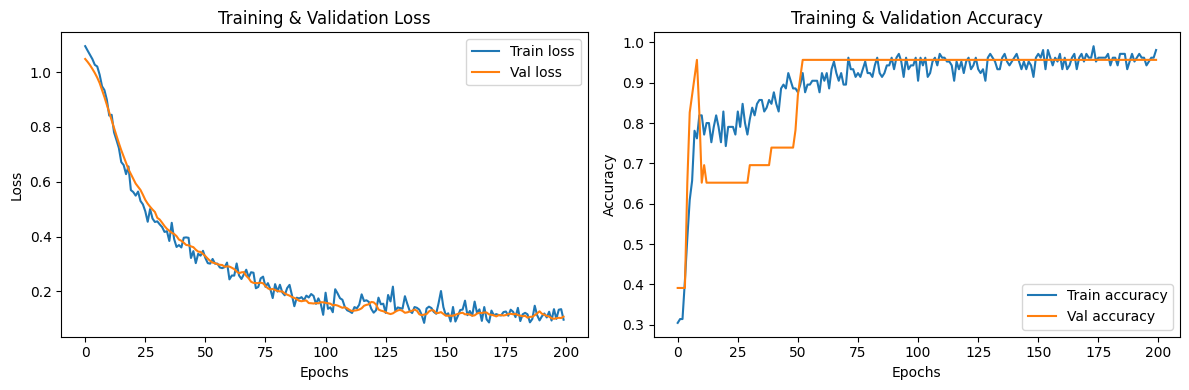

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epoch_count, train_loss_values, label="Train loss")
ax1.plot(epoch_count, val_loss_values, label="Val loss")
ax1.set_title("Training & Validation Loss")
ax1.set_ylabel("Loss")
ax1.set_xlabel("Epochs")
ax1.legend()

ax2.plot(epoch_count, train_accuracy_values, label="Train accuracy")
ax2.plot(epoch_count, val_accuracy_values, label="Val accuracy")
ax2.set_title("Training & Validation Accuracy")
ax2.set_ylabel("Accuracy")
ax2.set_xlabel("Epochs")
ax2.legend()

plt.tight_layout()
plt.show()

## Evaluation

With training complete, we evaluate the model on the **test set** — data the model has never seen during training or validation — to get an unbiased estimate of its real-world performance.

In [20]:
data_idx = 17

X_t = X_train[data_idx]
X_t = torch.tensor(X_t, dtype=torch.float)

y_gt = y_train[data_idx]
y_gt = torch.tensor(y_gt, dtype=torch.long)

with torch.no_grad(): # telling pytorch to not use gradients to improve efficiency
    output = irisNet(X_t)
    print(f"Output: {output.argmax()}")

print(f"Ground truth: {y_gt}")

Output: 2
Ground truth: 2


In [21]:
loss_test = 0
test_correct = 0
test_total = 0

irisNet.eval()
for i, data in enumerate(test_loader, 0):

    X = data[0]
    y = data[1]

    with torch.no_grad():

        # 1. Forward pass
        y_pred = irisNet(X)
        y_pred_class = y_pred.argmax(dim=1)

        # 2. Loss & accuracy calculation
        loss = loss_fn(y_pred, y)
        test_correct += (y_pred_class == y).sum().item()
        test_total += len(y)
    
    loss_test += loss

test_accuracy = test_correct / test_total
print(f"Testing loss: {loss_test/len(test_loader)}  |  Testing acc: {test_accuracy}")

Testing loss: 0.025054853409528732  |  Testing acc: 1.0
